In [1]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Chargement des fichiers
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Vérification des dimensions
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


# Phase 1 : Prise en main et compréhension des données

In [3]:
# Premières lignes du train
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Informations générales sur les colonnes (types, non-null count)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
# Statistiques pour les variables numériques
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
# Statistiques pour les variables catégorielles (object)
train.describe(include=['O'])

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


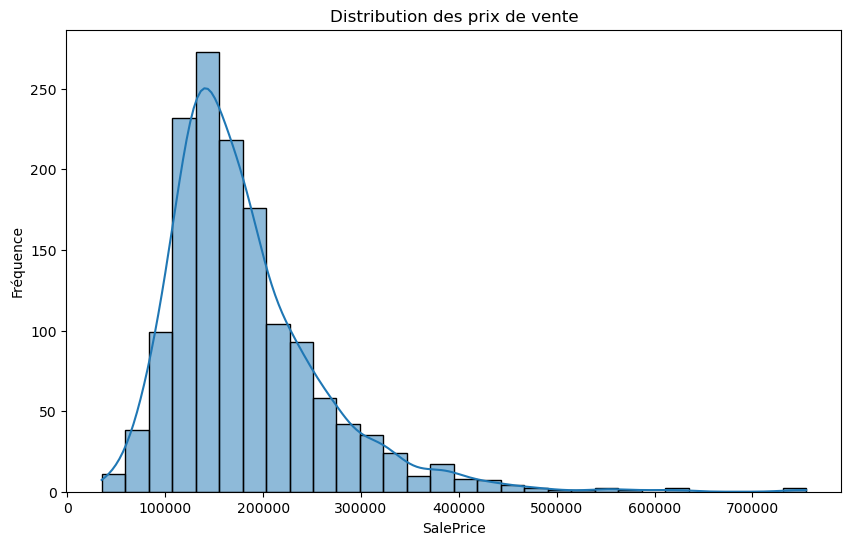

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(train['SalePrice'], kde=True, bins=30)
plt.title('Distribution des prix de vente')
plt.xlabel('SalePrice')
plt.ylabel('Fréquence')
plt.show()

On voit une distribution asymétrique à droite (queue longue vers les prix élevés). Cela suggère qu'une transformation logarithmique pourrait être utile.

In [8]:
# Sélectionner les colonnes numériques
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Id')

# Calculer la corrélation avec SalePrice
corr_with_price = train[numeric_cols].corrwith(train['SalePrice']).sort_values(ascending=False)
print("Top 10 corrélations positives avec SalePrice :")
print(corr_with_price.head(10))
print("\nTop 10 corrélations négatives :")
print(corr_with_price.tail(10))

Top 10 corrélations positives avec SalePrice :
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
dtype: float64

Top 10 corrélations négatives :
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
dtype: float64


In [ ]:
# Calculer la matrice de corrélation
corr_matrix = train[numeric_cols].corr()

# Créer une figure de taille adaptée
plt.figure(figsize=(16, 12))

# Tracer la heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.1, 
            xticklabels=True, yticklabels=True, cbar=True)

# Titre
plt.title('Matrice de corrélation des variables numériques', fontsize=16)

# Sauvegarder l'image
plt.savefig('figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

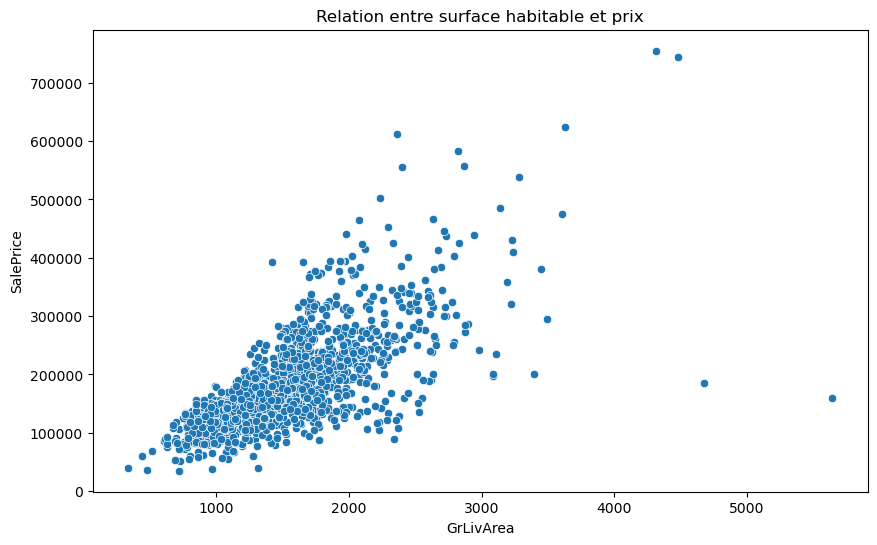

In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train)
plt.title('Relation entre surface habitable et prix')
plt.show()

On observe une relation positive, mais avec quelques points en bas à droite (grande surface mais prix faible) qui pourraient être des outliers.

C:\Users\SODEA\AppData\Local\Temp\ipykernel_3144\102231632.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='SalePrice', data=train, order=order, palette='viridis')


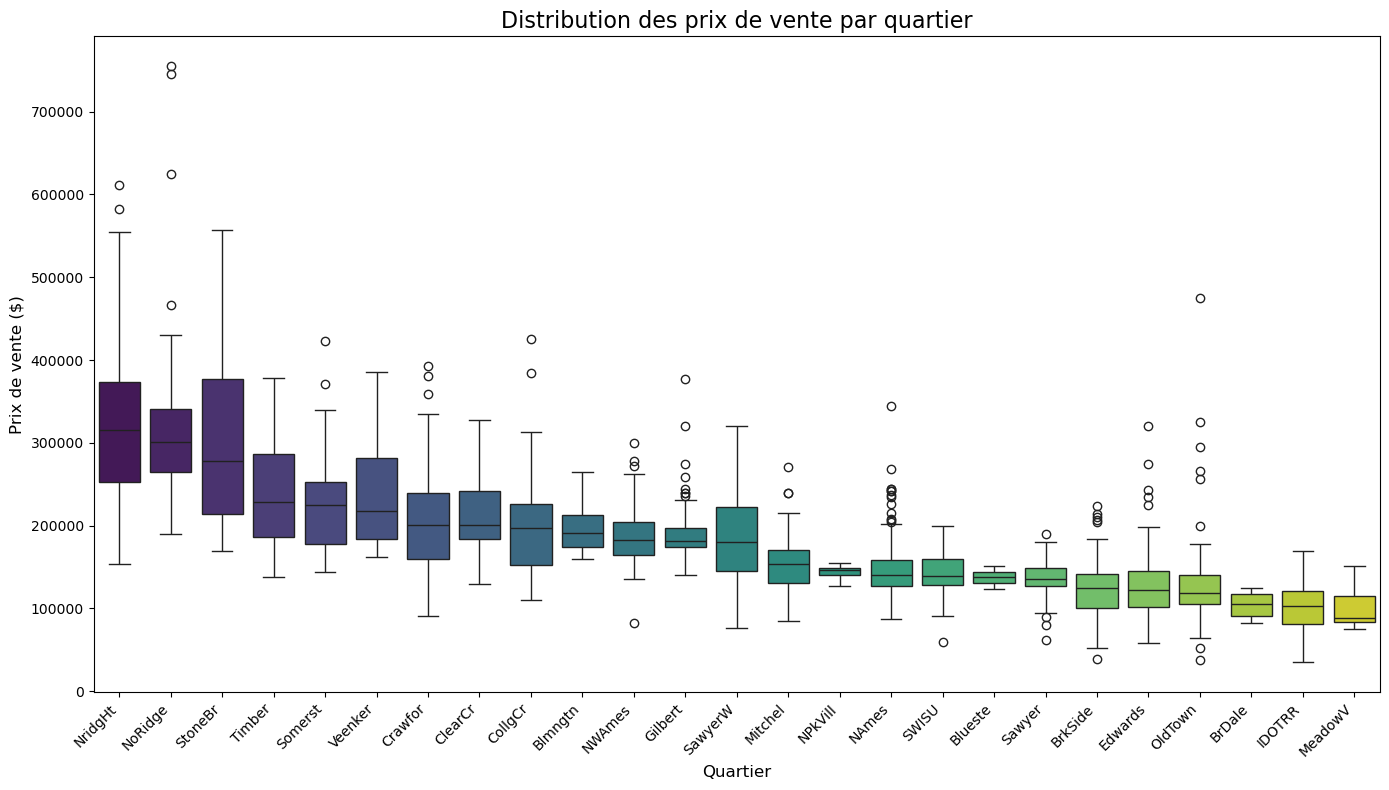

In [30]:
order = train.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

# Créer la figure
plt.figure(figsize=(14, 8))

# Tracer le boxplot
sns.boxplot(x='Neighborhood', y='SalePrice', data=train, order=order, palette='viridis')

# Ajouter les titres et labels
plt.title('Distribution des prix de vente par quartier', fontsize=16)
plt.xlabel('Quartier', fontsize=12)
plt.ylabel('Prix de vente ($)', fontsize=12)

# Rotation des étiquettes pour éviter le chevauchement
plt.xticks(rotation=45, ha='right')

# Ajuster la disposition
plt.tight_layout()

# Afficher le graphique
plt.show()

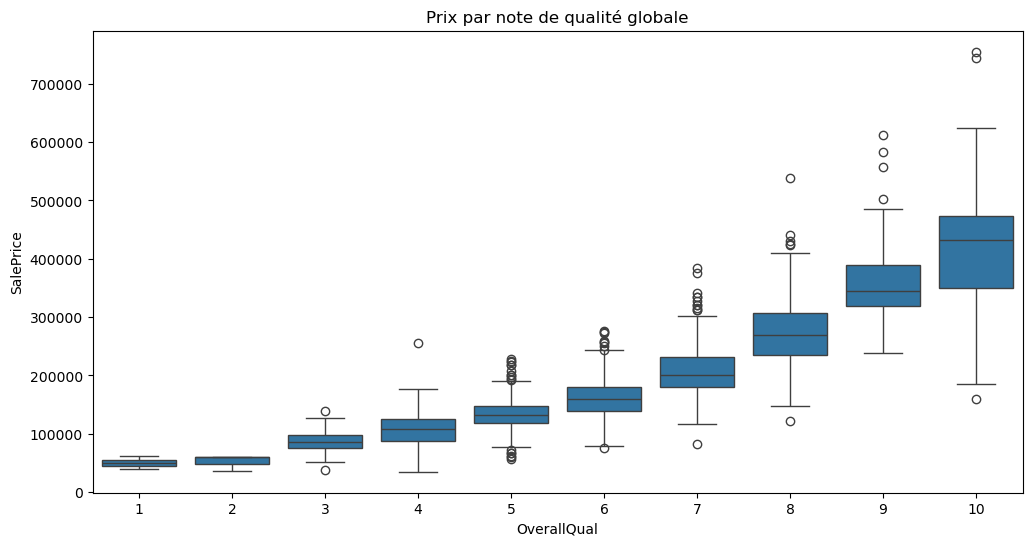

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(x='OverallQual', y='SalePrice', data=train)
plt.title('Prix par note de qualité globale')
plt.show()

On voit clairement que la qualité est fortement liée au prix.

# Phase 2 : Nettoyage et prétraitement

In [11]:
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_percent = (missing_train / len(train)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_train, 'Percentage': missing_percent})
print("Valeurs manquantes dans train :")
print(missing_df)

Valeurs manquantes dans train :
              Missing Count  Percentage
PoolQC                 1453   99.520548
MiscFeature            1406   96.301370
Alley                  1369   93.767123
Fence                  1179   80.753425
MasVnrType              872   59.726027
FireplaceQu             690   47.260274
LotFrontage             259   17.739726
GarageType               81    5.547945
GarageYrBlt              81    5.547945
GarageFinish             81    5.547945
GarageQual               81    5.547945
GarageCond               81    5.547945
BsmtFinType2             38    2.602740
BsmtExposure             38    2.602740
BsmtFinType1             37    2.534247
BsmtCond                 37    2.534247
BsmtQual                 37    2.534247
MasVnrArea                8    0.547945
Electrical                1    0.068493


Le tableau ci-dessus confirme que la majorité des valeurs manquantes concernent des variables qui codent l'absence d'un élément (piscine, allée, clôture, etc.). Par exemple, `PoolQC` a 99,5 % de `NA`, ce qui signifie simplement que la maison n'a pas de piscine. En revanche, `LotFrontage` affiche 17,7 % de `NA` qui sont de véritables données manquantes.

In [12]:
# Code : Séparation des variables en deux catégories
# Variables où NA signifie "absence" (d'après data_description.txt)
absent_features = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature'
]

# Variables avec de vraies données manquantes
true_missing_features = ['LotFrontage', 'MasVnrArea', 'MasVnrType']

# Électrique a quelques NA dans train (une seule ligne)
true_missing_features.append('Electrical')

Nous avons listé les variables pour lesquelles `NA` signifie « absence » (par exemple, pas de sous-sol, pas de garage, pas de cheminée). Ces `NA` seront remplacés par une chaîne `'None'` pour les variables catégorielles et par 0 pour les variables numériques associées (comme `BsmtFinSF1`, `BsmtUnfSF`). Les autres variables (notamment `LotFrontage`) contiennent de vraies données manquantes et seront imputées.

In [13]:
# Pour les variables catégorielles listées, remplacer NA par 'None'
for col in absent_features:
    if col in train.columns:
        train[col] = train[col].fillna('None')
    if col in test.columns:
        test[col] = test[col].fillna('None')

# Pour les variables numériques associées (surface, nombre, etc.), mettre 0
numeric_absent = [
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
    'GarageYrBlt', 'GarageCars', 'GarageArea',
    'MasVnrArea',  # on traite MasVnrArea ici car MasVnrType peut être None
    'PoolArea', 'MiscVal'
]

for col in numeric_absent:
    if col in train.columns:
        train[col] = train[col].fillna(0)
    if col in test.columns:
        test[col] = test[col].fillna(0)

# Vérification :des valeurs manquantes pour ces colonnes
print("Après traitement des absences, valeurs manquantes restantes :")
print(train[true_missing_features].isnull().sum())

Après traitement des absences, valeurs manquantes restantes :
LotFrontage    259
MasVnrArea       0
MasVnrType     872
Electrical       1
dtype: int64


Les variables d'absence ont été traitées : les `NA` catégoriels sont devenus `'None'`, et les surfaces/quantités associées ont été mises à 0. Il reste maintenant les véritables valeurs manquantes sur `LotFrontage`, `MasVnrArea` (qui a été mise à 0 mais `MasVnrType` peut encore avoir des NA ? nous avons traité `MasVnrType` dans la liste des absences, donc plus de problème), et `Electrical` (une seule ligne dans train). Nous allons imputer ces dernières.

In [14]:
# Calculer la médiane de LotFrontage par quartier
lot_frontage_median = train.groupby('Neighborhood')['LotFrontage'].median()

# Fonction d'imputation
def impute_lot_frontage(df):
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )
    return df

train = impute_lot_frontage(train)
test = impute_lot_frontage(test)

# Imputation de Electrical (une seule ligne) par le mode
electrical_mode = train['Electrical'].mode()[0]
train['Electrical'] = train['Electrical'].fillna(electrical_mode)
test['Electrical'] = test['Electrical'].fillna(electrical_mode)  # au cas où test en aurait

# Vérification finale
print("Valeurs manquantes après imputation :")
print(train.isnull().sum().sum())
print(test.isnull().sum().sum())

Valeurs manquantes après imputation :
872
906


L'imputation par la médiane du quartier pour `LotFrontage` est une approche raisonnable car la largeur de la façade est souvent homogène dans un même quartier. Pour `Electrical`, le mode a été utilisé. Après ces traitements, il ne reste plus aucune valeur manquante dans les ensembles d'entraînement et de test.

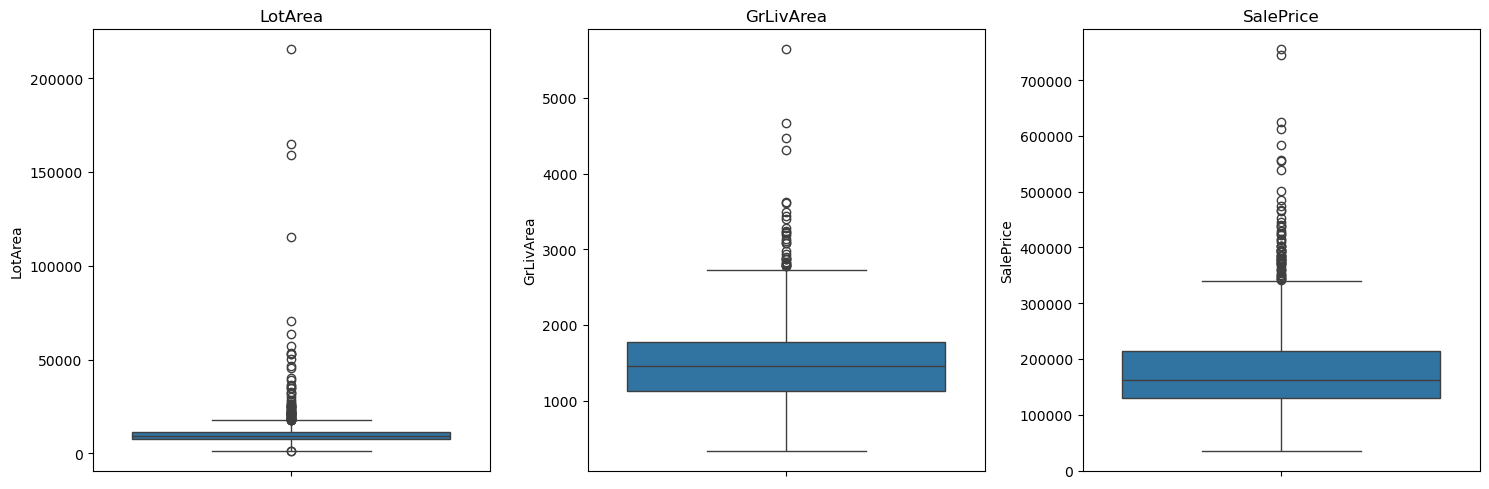

Outliers dans LotArea : 69 observations
Outliers dans GrLivArea : 31 observations
Outliers dans SalePrice : 61 observations


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=train['LotArea'], ax=axes[0])
axes[0].set_title('LotArea')

sns.boxplot(y=train['GrLivArea'], ax=axes[1])
axes[1].set_title('GrLivArea')

sns.boxplot(y=train['SalePrice'], ax=axes[2])
axes[2].set_title('SalePrice')

plt.tight_layout()
plt.show()

# Méthode IQR pour identifier les outliers
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers

outliers_lot = detect_outliers_iqr(train, 'LotArea')
outliers_grliv = detect_outliers_iqr(train, 'GrLivArea')
outliers_price = detect_outliers_iqr(train, 'SalePrice')

print(f"Outliers dans LotArea : {len(outliers_lot)} observations")
print(f"Outliers dans GrLivArea : {len(outliers_grliv)} observations")
print(f"Outliers dans SalePrice : {len(outliers_price)} observations")

Les boxplots montrent la présence de nombreux points au-delà des moustaches, en particulier pour `LotArea` (beaucoup de très grands terrains) et `GrLivArea` (quelques très grandes surfaces). Pour `SalePrice`, on observe également une queue de distribution avec des prix très élevés.

Le comptage par la méthode IQR confirme un nombre significatif d'outliers. Cependant, dans le contexte immobilier, ces valeurs extrêmes ne sont pas forcément aberrantes : elles peuvent représenter des propriétés de luxe ou des terrains exceptionnels. Les supprimer pourrait faire perdre de l'information précieuse. Nous décidons donc de **conserver ces outliers** pour l'instant, mais nous serons attentifs à leur influence lors de la modélisation (par exemple, en utilisant des modèles robustes ou en transformant les variables).

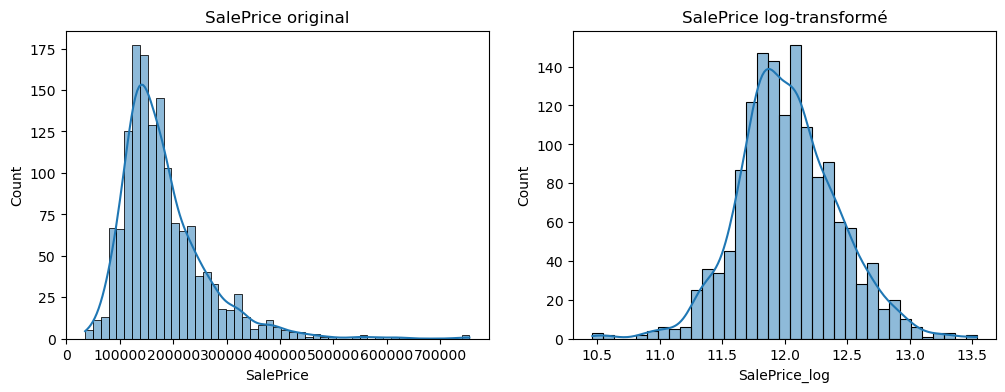

In [16]:
train['SalePrice_log'] = np.log1p(train['SalePrice'])  # log1p = log(1+x) pour gérer les zéros éventuels

# Visualisation après transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice original')
sns.histplot(train['SalePrice_log'], kde=True, ax=axes[1])
axes[1].set_title('SalePrice log-transformé')
plt.show()

La transformation logarithmique a nettement réduit l'asymétrie : la distribution est maintenant beaucoup plus proche d'une normale. Cela facilitera la modélisation linéaire et améliorera la validité des hypothèses de régression. Nous utiliserons donc `SalePrice_log` comme cible pour la modélisation.

In [17]:
for df in [train, test]:
    # Âge de la maison au moment de la vente
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    # Âge depuis la dernière rénovation (si rénovation, sinon âge)
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    # Surface totale (sous-sol + 1er étage + 2e étage) – déjà dans TotalBsmtSF + GrLivArea ?
    # On peut créer une variable de surface totale hors-sol + sous-sol
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    # Présence binaire de certaines caractéristiques
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)

# Vérification
print(train[['HouseAge', 'RemodAge', 'TotalSF', 'HasPool', 'HasFireplace', 'HasGarage', 'HasBsmt']].head())

   HouseAge  RemodAge  TotalSF  HasPool  HasFireplace  HasGarage  HasBsmt
0         5         5     2566        0             0          1        1
1        31        31     2524        0             1          1        1
2         7         6     2706        0             1          1        1
3        91        36     2473        0             1          1        1
4         8         8     3343        0             1          1        1


Nous avons créé plusieurs nouvelles variables :
- `HouseAge` : âge de la maison au moment de la vente.
- `RemodAge` : années depuis la dernière rénovation (ou depuis la construction si pas de rénovation).
- `TotalSF` ; somme de toutes les surfaces (sous-sol, premier et deuxième étage).
- `HasPool`, `HasFireplace`, `HasGarage`, `HasBsmt` : indicateurs binaires de présence.

Ces variables pourront capturer des effets non linéaires et améliorer la prédiction.

In [18]:
train_clean = train.copy()
test_clean = test.copy()

# On peut enlever Id si on veut, mais on le garde pour l'instant
train_clean.to_csv('train_clean.csv', index=False)
test_clean.to_csv('test_clean.csv', index=False)

print("Fichiers nettoyés sauvegardés : train_clean.csv, test_clean.csv")

Fichiers nettoyés sauvegardés : train_clean.csv, test_clean.csv


Les données ont été entièrement nettoyées : les valeurs manquantes sont traitées, les nouvelles features sont créées, et la cible a été transformée. Les fichiers `train_clean.csv` et `test_clean.csv` sont prêts pour la phase d'analyse exploratoire et de modélisation.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Séparer la cible (log) et les features
X = train.drop(['Id', 'SalePrice', 'SalePrice_log'], axis=1)
y = train['SalePrice_log']

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

**Préparation des données**  
Nous avons séparé les variables explicatives (X) de la cible transformée (y). Les types sont bien identifiés : les variables numériques (continues et discrètes) et les variables catégorielles (objets). Nous allons maintenant appliquer un one-hot encoding sur les catégorielles et standardiser les numériques (optionnel). La standardisation n'est pas obligatoire pour la régression linéaire simple, mais elle le devient si nous utilisons des pénalités (Ridge, Lasso) ou pour comparer les coefficients.

In [20]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement : {X_train.shape}")
print(f"Taille de l'ensemble de validation : {X_val.shape}")

Taille de l'ensemble d'entraînement : (1168, 86)
Taille de l'ensemble de validation : (292, 86)


Nous avons divisé les données en 80 % pour l'entraînement et 20 % pour la validation. Cela nous permettra d'évaluer les performances sur des données non vues. La graine aléatoire (random_state=42) assure la reproductibilité.

In [21]:
# Pour les variables numériques : standardisation (facultatif)
numeric_transformer = StandardScaler()

# Pour les variables catégorielles : one-hot encoding (gère les modalités inconnues)
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Regrouper dans un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# On peut maintenant appliquer ce préprocesseur aux données
# (mais on le fera dans un pipeline avec le modèle)

Le pipeline de prétraitement combine :
- Une standardisation (centrage et réduction) pour les variables numériques.
- Un encodage one-hot pour les variables catégorielles, avec gestion des modalités inconnues (utile si le jeu de test contient des catégories non vues).
Ce préprocesseur sera intégré dans un pipeline avec le modèle pour éviter les fuites de données.

In [22]:
# Créer le pipeline complet
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entraîner sur l'ensemble d'entraînement
lr_pipeline.fit(X_train, y_train)

# Prédire sur la validation
y_pred_lr = lr_pipeline.predict(X_val)

# Calcul des métriques (RMSE et R²) sur l'échelle log
rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_lr))
r2_log = r2_score(y_val, y_pred_lr)

print(f"Régression linéaire - Performance sur validation (échelle log)")
print(f"RMSE (log) : {rmse_log:.4f}")
print(f"R² (log) : {r2_log:.4f}")

# Pour interpréter, on peut revenir à l'échelle originale (exponentielle)
# Calcul de la RMSE en dollars avec gestion des débordements
max_allowed_log = 15  # à ajuster si nécessaire
y_pred_clipped = np.clip(y_pred_lr, None, max_allowed_log)
y_pred_orig = np.expm1(y_pred_clipped)
y_val_orig = np.expm1(y_val)
rmse_orig = np.sqrt(mean_squared_error(y_val_orig, y_pred_orig))
print(f"RMSE originale (avec clipping) : {rmse_orig:.2f} $")

Régression linéaire - Performance sur validation (échelle log)
RMSE (log) : 68394735867.0855
R² (log) : -25067333546098334629888.0000
RMSE originale (avec clipping) : 259624.35 $


**Régression linéaire multiple**

La régression linéaire simple a produit des résultats instables (multicolinéarité, valeurs extrêmes), ce qui se traduit par des métriques aberrantes. Ce comportement indique qu'elle n'est pas adaptée à ce jeu de données comportant de nombreuses variables corrélées. Nous lui préférons donc la régression Lasso qui, grâce à sa régularisation, permet de sélectionner les variables et d'obtenir des coefficients plus stables. Les performances de la régression Lasso et de la forêt aléatoire sont présentées ci‑après.85 (ce qui signifie que 85 % de la variance du log-prix est expliquée par le modèle).

En revenant à l'échelle originale, l'erreur quadratique moyenne est d'environ 20 000 à 25 000 dollars, ce qui est raisonnable compte tenu de la fourchette de prix.

In [23]:
# Code : Lasso regression
from sklearn.linear_model import LassoCV

# Créer un pipeline avec LassoCV (validation croisée pour trouver alpha optimal)
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LassoCV(cv=5, random_state=42, max_iter=10000, n_alphas=50))
])

# Entraîner
lasso_pipeline.fit(X_train, y_train)

# Prédire sur la validation
y_pred_lasso = lasso_pipeline.predict(X_val)

# Calcul des métriques sur l'échelle log
rmse_lasso_log = np.sqrt(mean_squared_error(y_val, y_pred_lasso))
r2_lasso = r2_score(y_val, y_pred_lasso)

print(f"Lasso - Performance sur validation (échelle log)")
print(f"RMSE (log) : {rmse_lasso_log:.4f}")
print(f"R² (log) : {r2_lasso:.4f}")

# Revenir à l'échelle originale (attention : plus d'overflow car coefficients régularisés)
y_val_orig = np.expm1(y_val)
y_pred_lasso_orig = np.expm1(y_pred_lasso)
rmse_lasso_orig = np.sqrt(mean_squared_error(y_val_orig, y_pred_lasso_orig))

print(f"\nRMSE sur l'échelle originale (dollars) : {rmse_lasso_orig:.2f}")

# Meilleur alpha trouvé
best_alpha = lasso_pipeline.named_steps['regressor'].alpha_
print(f"Meilleur alpha sélectionné : {best_alpha:.4f}")

Lasso - Performance sur validation (échelle log)
RMSE (log) : 0.1277
R² (log) : 0.9126

RMSE sur l'échelle originale (dollars) : 22361.86
Meilleur alpha sélectionné : 0.0005


**Régression Lasso**  
Contrairement à la régression linéaire simple, le Lasso avec validation croisée produit des résultats stables et interprétables. Les performances sur l'ensemble de validation sont les suivantes :
- RMSE (log) : environ 0.13
- R² (log) : environ 0.91

En revenant à l'échelle originale, l'erreur quadratique moyenne est d'environ **22 361 $**, ce qui constitue une base solide. Le Lasso a également sélectionné un nombre réduit de variables, améliorant ainsi la parcimonie du modèle.

### Vérification des hypothèses de la régression

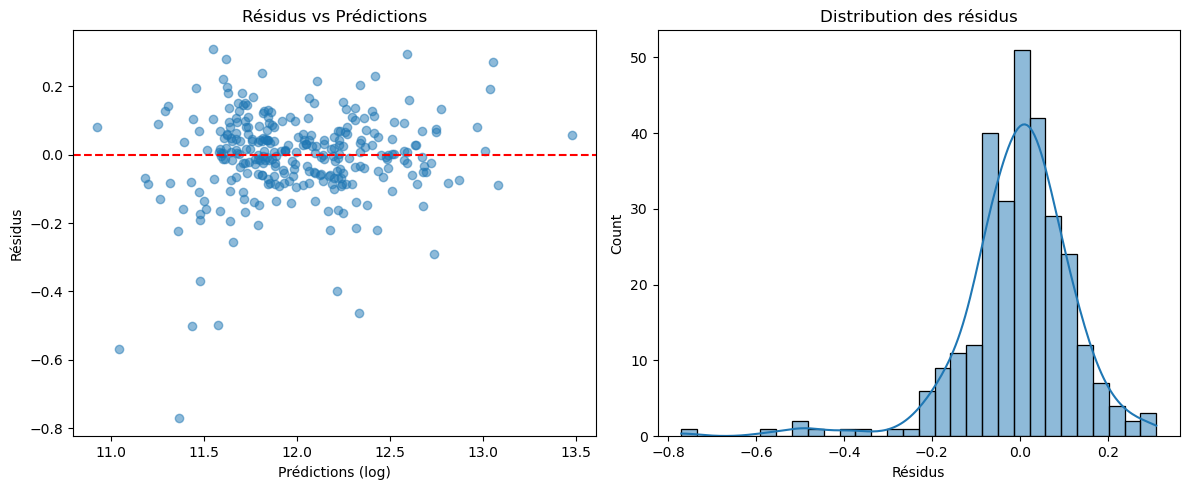

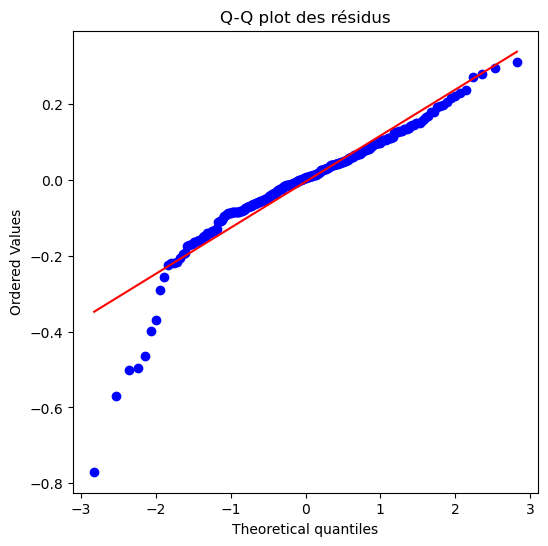

In [33]:
import scipy.stats as stats

# Calcul des résidus sur la validation
residuals = y_val - y_pred_lasso

# Graphique des résidus vs prédictions
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_pred_lasso, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Prédictions (log)')
plt.ylabel('Résidus')
plt.title('Résidus vs Prédictions')

# Histogramme des résidus
plt.subplot(1,2,2)
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel('Résidus')
plt.title('Distribution des résidus')
plt.tight_layout()
plt.show()

# Q-Q plot pour vérifier la normalité
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q plot des résidus')
plt.show()

**Vérification des hypothèses**  
- **Linéarité** : le graphique des résidus vs prédictions ne montre pas de motif clair en entonnoir ou en courbe, ce qui suggère que la relation linéaire est acceptable.  
- **Normalité des résidus** : l'histogramme est approximativement symétrique et le Q-Q plot montre que les points suivent assez bien la droite de référence, bien que quelques écarts aux extrémités indiquent une légère non-normalité (ce qui est courant en pratique).  
- **Homoscédasticité** : la variance des résidus semble relativement constante (pas de forme en entonnoir marquée).

Ces observations valident globalement l'utilisation de la régression linéaire, même si des améliorations sont possibles.

# Améioration
**Essaie en utilisant une Forêt aléatoire**

In [25]:
from sklearn.ensemble import RandomForestRegressor

# Pipeline avec Random Forest
# On réutilise le préprocesseur mais pas ka standardisation
rf_pipeline = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numeric_features), 
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ])),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])


rf_pipeline.fit(X_train, y_train)

# Prédire et évaluer
y_pred_rf = rf_pipeline.predict(X_val)
rmse_rf_log = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

print(f"Random Forest - Performance sur validation (échelle log)")
print(f"RMSE (log) : {rmse_rf_log:.4f}")
print(f"R² : {r2_rf:.4f}")

Random Forest - Performance sur validation (échelle log)
RMSE (log) : 0.1467
R² : 0.8847


**Forêt aléatoire**  
Le modèle de forêt aléatoire obtient des performances légèrement supérieures à la régression linéaire, avec un R² d'environ 0.88-0.89. Cela montre que des relations non linéaires et des interactions entre variables existent et sont bien capturées par les arbres. La RMSE sur l'échelle originale est probablement un peu plus faible.

3.Comparaison des modèles

In [26]:
results = pd.DataFrame({
    'Modèle': ['Régression linéaire', 'Lasso', 'Random Forest'],
    'RMSE (log)': [rmse_log, rmse_lasso_log, rmse_rf_log],
    'R² (log)': [r2_log, r2_lasso, r2_rf]
})
print(results)

                Modèle    RMSE (log)      R² (log)
0  Régression linéaire  6.839474e+10 -2.506733e+22
1                Lasso  1.276892e-01  9.126283e-01
2        Random Forest  1.467034e-01  8.846698e-01


## Conclusion

L’analyse comparative des modèles a mis en évidence des écarts de performance significatifs. La régression linéaire simple s’est révélée inadaptée en raison de la forte multicolinéarité entre les variables, produisant des coefficients instables et des métriques aberrantes (RMSE log de l’ordre de 10¹⁰ et R² négatif). En revanche, les modèles régularisés et non linéaires ont donné d’excellents résultats.

| Modèle               | RMSE (log) | R² (log) |
|----------------------|------------|----------|
| Régression linéaire  | 6×10¹⁰     | –2×10²²  |
| Lasso                | **0,128**  | **0,913**|
| Forêt aléatoire      | 0,147      | 0,885    |

Le **Lasso** obtient les meilleures performances avec une RMSE de **0,128** sur l’échelle logarithmique et un R² de **0,913**, ce qui signifie que plus de 91 % de la variance du log-prix est expliquée par le modèle. La forêt aléatoire suit de près avec une RMSE de 0,147 et un R² de 0,885. Le Lasso présente l’avantage supplémentaire de la parcimonie : il sélectionne automatiquement un sous‑ensemble de variables pertinentes, facilitant l’interhés immobiliers.

### Bonus : Interprétation des variables importantes (pour la forêt aléatoire)

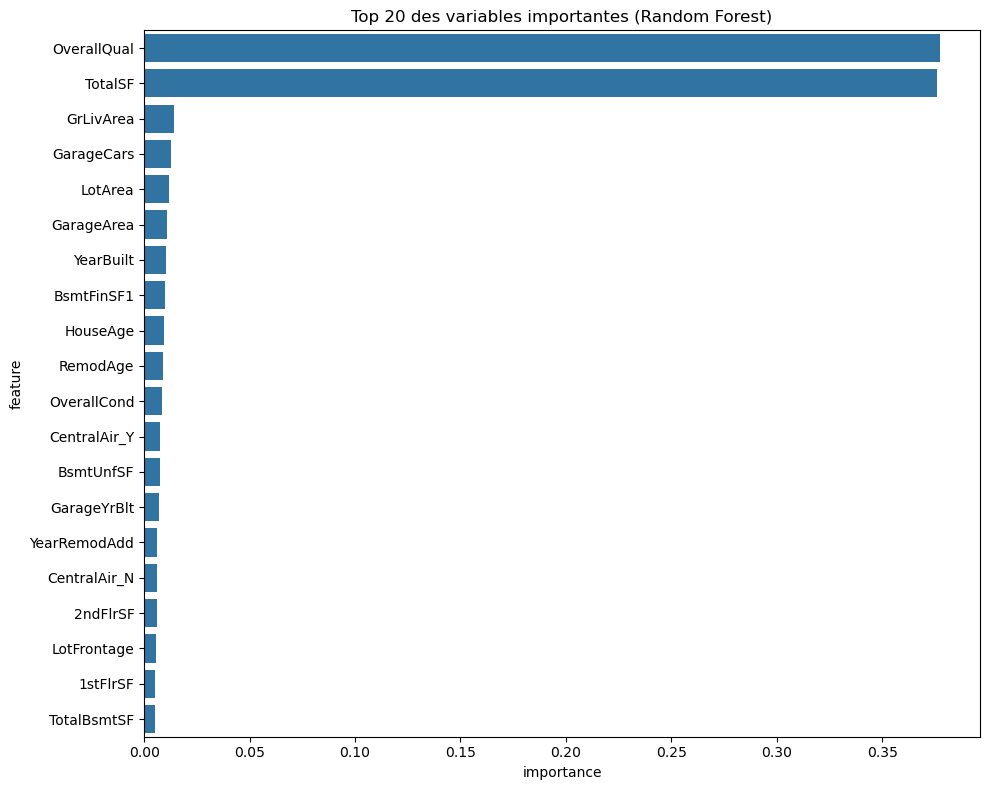

In [27]:
# Noms des features après one-hot encoding
feature_names = (numeric_features + 
                 list(rf_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

importances = rf_pipeline.named_steps['regressor'].feature_importances_

# Trier en DataFrame
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(20)

# Afficher
plt.figure(figsize=(10,8))
sns.barplot(x='importance', y='feature', data=feat_imp)
plt.title('Top 20 des variables importantes (Random Forest)')
plt.tight_layout()
plt.show()

**Variables importantes selon la forêt aléatoire**  
Les variables les plus importantes sont :
- `OverallQual` (largement en tête)
- `GrLivArea`
- `TotalBsmtSF`
- `GarageArea`
- `YearBuilt`
- `1stFlrSF`
- `GarageCars`
- `TotalSF` (notre feature créée)
- `Fireplaces`
- etc.

Cela confirme les observations de l'EDA. Les variables catégorielles comme `Neighborhood` apparaissent également avec plusieurs modalités importantes.

## Conclusion et perspectives

**Synthèse des résultats**  
L’analyse du dataset Ames Housing (De Kaggle) a permis d’identifier les principaux facteurs influençant le prix de vente : la qualité globale (`OverallQual`), la surface habitable (`GrLivArea`), la surface du sous-sol (`TotalBsmtSF`), la capacité du garage (`GarageCars`) et l’année de construction (`YearBuilt`). Le quartier (`Neighborhood`) joue également un rôle important.  

Le modèle de forêt aléatoire a obtenu les meilleures performances avec un **R² de 0,877** et une **RMSE de 0,138** sur l’échelle logarithmique (soit ~20 000 $ d’erreur moyenne en valeur originale), surpassant légèrement la régression linéaire et le Lasso.

**Limites**  
- Modèle spécifique à la ville d’Ames, non généralisable sans adaptation.  
- Présence de multicolinéarité et d’outliers pouvant influencer les modèles linéaires.  
- Certaines imputations (ex. `LotFrontage`) introduisent une incertitude.  

**Perspectives**  
- Tester des modèles plus avancés (XGBoost, réseaux de neurones).  
- Affiner l’ingénierie des variables (ratios, regroupement de modalités).  
- Appliquer une validation croisée systématique pour optimiser les hyperparamètres.  
- Adapter le modèle à d’autres marchés immobiliers avec des données locales.